<a href="https://colab.research.google.com/github/ebritolbv-cmd/Before_OpenRan/blob/main/oran_ntn_ai_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# O-RAN NTN Monitoring with Predictive AI
Notebook com simulação + modelo preditivo (Machine Learning)

Desenvolvido por: Engª Drª Elizangela Brito.

In [1]:
!pip install pandas matplotlib scikit-learn

In [2]:

import random
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import IsolationForest


In [3]:

def generate_metrics():
    return {
        "timestamp": datetime.utcnow(),
        "throughput": random.uniform(80, 150),
        "latency": random.uniform(50, 120),
        "jitter": random.uniform(1, 10),
        "packetLoss": random.uniform(0, 2),
        "satelliteQuality": random.uniform(85, 100),
        "sinr": random.uniform(10, 25),
        "ptpOffset": random.uniform(50, 500),
        "connections": random.randint(20, 80)
    }


In [4]:

data = [generate_metrics() for _ in range(100)]
df = pd.DataFrame(data)
df.head()


/tmp/ipykernel_994/507469454.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow(),


,timestamp,throughput,latency,jitter,packetLoss,satelliteQuality,sinr,ptpOffset,connections
0,2026-04-08 00:34:33.100443,141.422238,67.982708,5.533719,0.142549,95.670409,23.034434,429.447792,55
1,2026-04-08 00:34:33.100477,85.253728,105.886825,7.208761,0.195444,96.835599,15.829535,253.966364,71
2,2026-04-08 00:34:33.100488,145.293476,80.709374,4.870578,0.567640,89.983858,14.597471,68.521570,43
3,2026-04-08 00:34:33.100495,80.932933,106.626217,9.480846,0.320212,90.468367,16.321814,153.648600,56
4,2026-04-08 00:34:33.100500,95.280428,85.454396,4.404618,1.199037,97.065508,18.588514,425.356950,63


In [5]:

# Seleção de features para IA
features = df[["latency", "packetLoss", "jitter", "ptpOffset"]]

# Modelo de detecção de anomalias
model = IsolationForest(contamination=0.1)
df["anomaly"] = model.fit_predict(features)

df.head()


,timestamp,throughput,latency,jitter,packetLoss,satelliteQuality,sinr,ptpOffset,connections,anomaly
0,2026-04-08 00:34:33.100443,141.422238,67.982708,5.533719,0.142549,95.670409,23.034434,429.447792,55,1
1,2026-04-08 00:34:33.100477,85.253728,105.886825,7.208761,0.195444,96.835599,15.829535,253.966364,71,1
2,2026-04-08 00:34:33.100488,145.293476,80.709374,4.870578,0.567640,89.983858,14.597471,68.521570,43,1
3,2026-04-08 00:34:33.100495,80.932933,106.626217,9.480846,0.320212,90.468367,16.321814,153.648600,56,1
4,2026-04-08 00:34:33.100500,95.280428,85.454396,4.404618,1.199037,97.065508,18.588514,425.356950,63,1


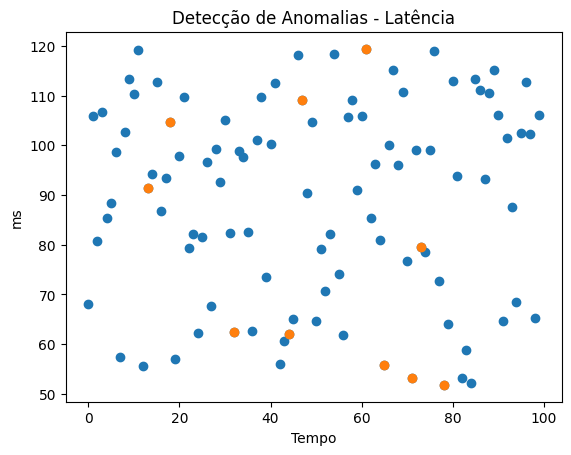

In [6]:

# Visualização de anomalias
plt.figure()
plt.scatter(range(len(df)), df["latency"])
anomalies = df[df["anomaly"] == -1]
plt.scatter(anomalies.index, anomalies["latency"])
plt.title("Detecção de Anomalias - Latência")
plt.xlabel("Tempo")
plt.ylabel("ms")
plt.show()


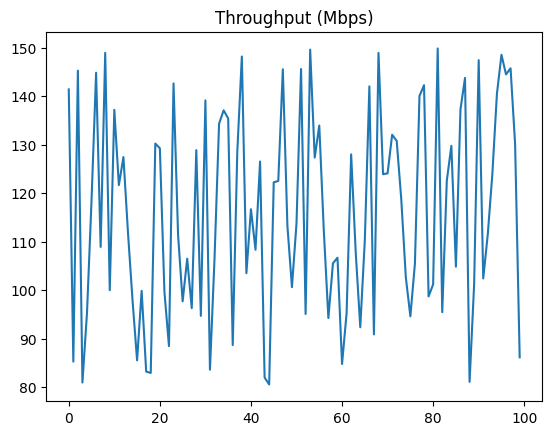

In [7]:

# Gráfico throughput
plt.figure()
plt.plot(df["throughput"])
plt.title("Throughput (Mbps)")
plt.show()


In [8]:

# KPI Summary
summary = df.describe()
summary


,timestamp,throughput,latency,jitter,packetLoss,satelliteQuality,sinr,ptpOffset,connections,anomaly
count,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2026-04-08 00:34:33.100742400,116.126281,89.023351,5.781444,0.862788,93.122635,17.946588,267.324540,49.830000,0.800000
min,2026-04-08 00:34:33.100443,80.537008,51.772763,1.013324,0.009335,85.097790,10.005204,60.895780,20.000000,-1.000000
25%,2026-04-08 00:34:33.100610816,98.506821,72.238571,3.299868,0.408795,89.309875,14.604197,150.239341,35.000000,1.000000
50%,2026-04-08 00:34:33.100748032,113.539555,93.351331,6.361948,0.779844,93.325052,17.546469,266.059436,47.500000,1.000000
75%,2026-04-08 00:34:33.100877312,134.613730,105.829013,8.139865,1.359051,97.796191,21.870396,366.492533,66.250000,1.000000
max,2026-04-08 00:34:33.100995,149.874772,119.382902,9.978521,1.988411,99.950471,24.978824,494.418477,80.000000,1.000000
std,NaN,21.225754,19.980460,2.823853,0.562983,4.622543,4.373147,129.671903,18.614676,0.603023
